In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('heart.csv')
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


# EDA and Data clening

In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

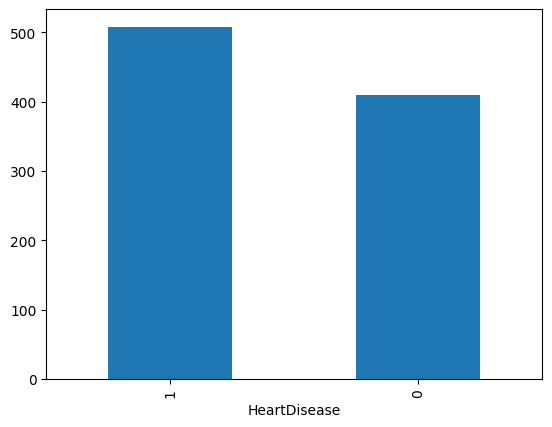

In [9]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [10]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [11]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

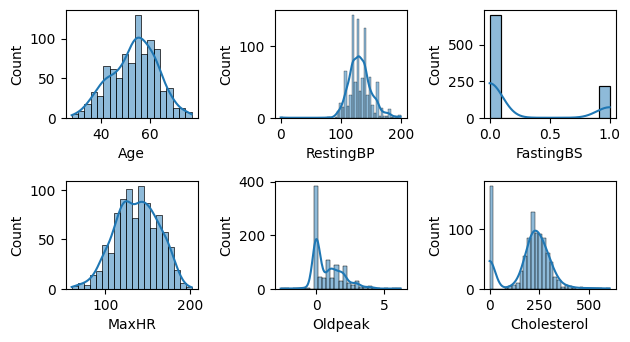

In [12]:
def ploting (var , num):
    plt.subplot(3 ,3 , num)
    sns.histplot(df[var] , kde = True)

ploting('Age' , 1)
ploting('RestingBP' , 2)
ploting('FastingBS' , 3)
ploting('MaxHR' , 4)
ploting('Oldpeak' , 5)
ploting('Cholesterol' , 6)


plt.tight_layout()


In [13]:
resting_bp_mean = df.loc[df['RestingBP'] != 0 , 'RestingBP'].mean()
resting_bp_mean

np.float64(132.54089422028352)

In [14]:
df['RestingBP'] = df['RestingBP'].replace(0 , resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [15]:
cholesterol_mean = df.loc[df['Cholesterol'] != 0 , 'Cholesterol'].mean()

In [16]:
df['Cholesterol'] = df['Cholesterol'].replace(0 , cholesterol_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

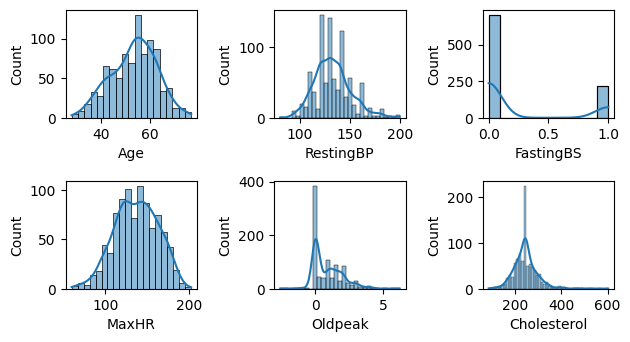

In [17]:
ploting('Age' , 1)
ploting('RestingBP' , 2)
ploting('FastingBS' , 3)
ploting('MaxHR' , 4)
ploting('Oldpeak' , 5)
ploting('Cholesterol' , 6)


plt.tight_layout()

In [18]:
pd.DataFrame(df)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


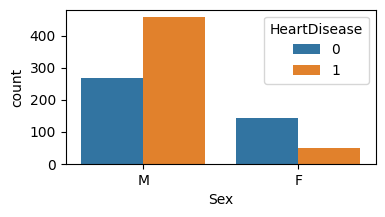

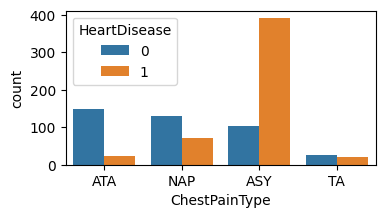

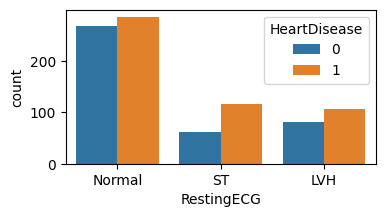

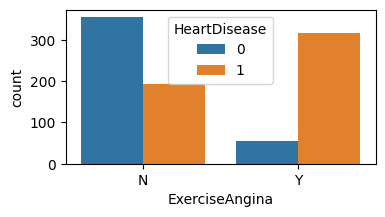

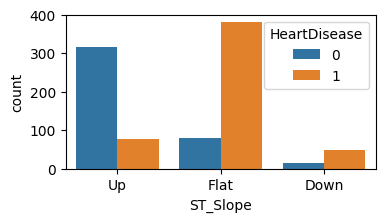

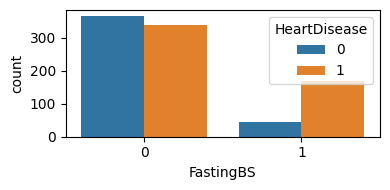

In [19]:
def bar(val, num , hue):
    plt.figure(figsize = (4 , 2))
    sns.countplot(x = df[val] , hue = df[hue])
    
bar('Sex' , 1 , 'HeartDisease')
bar('ChestPainType' , 2 , 'HeartDisease')
bar('RestingECG' , 3 , 'HeartDisease')
bar('ExerciseAngina' , 4 , 'HeartDisease')
bar('ST_Slope' , 5 , 'HeartDisease')
bar('FastingBS' , 6 , 'HeartDisease')
plt.tight_layout()


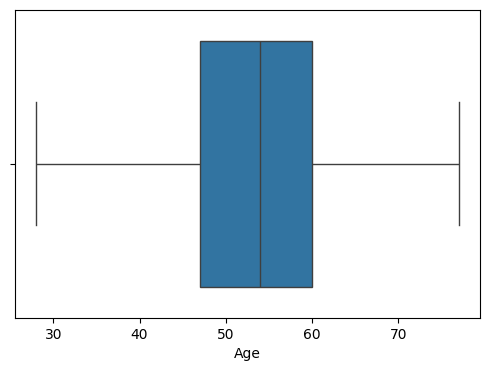

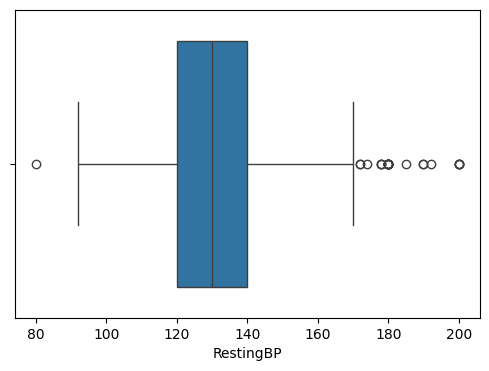

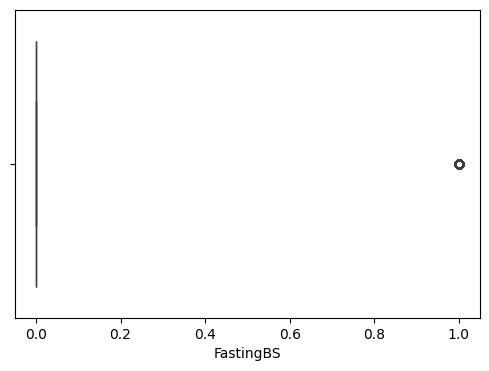

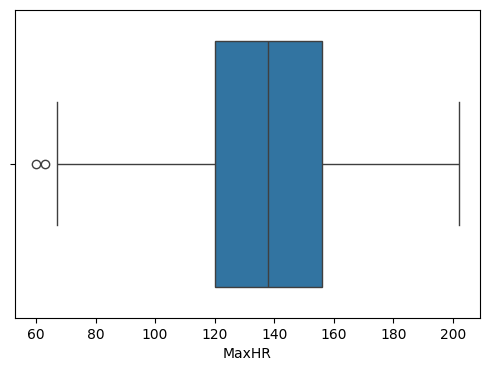

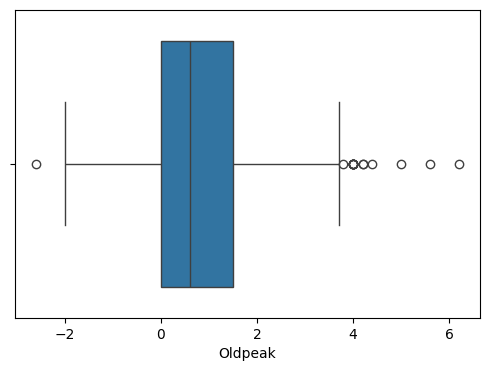

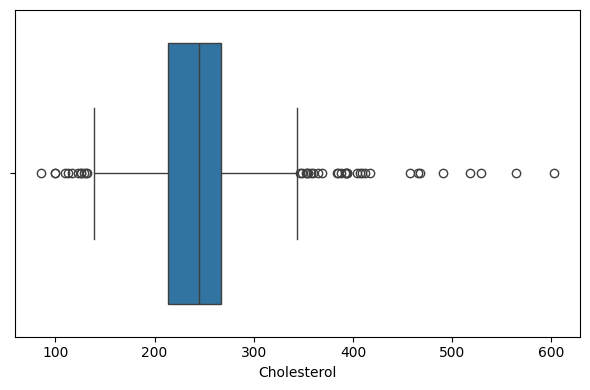

In [20]:
def box_ploting (var , num):
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[var])

box_ploting('Age' , 1)
box_ploting('RestingBP' , 2)
box_ploting('FastingBS' , 3)
box_ploting('MaxHR' , 4)
box_ploting('Oldpeak' , 5)
box_ploting('Cholesterol' , 6)


plt.tight_layout()

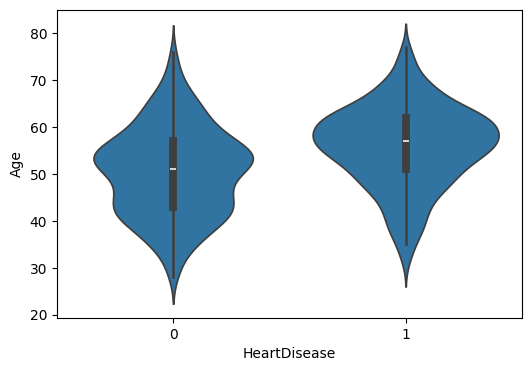

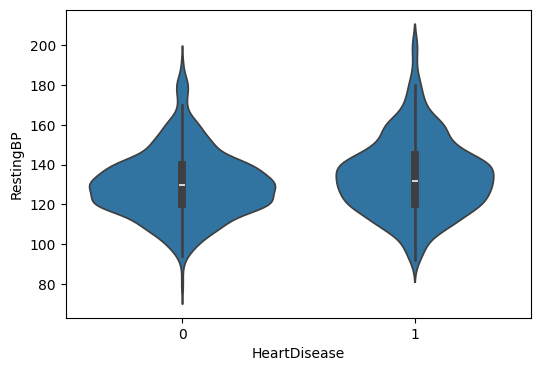

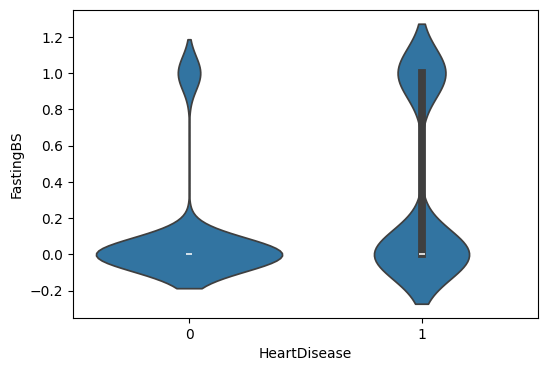

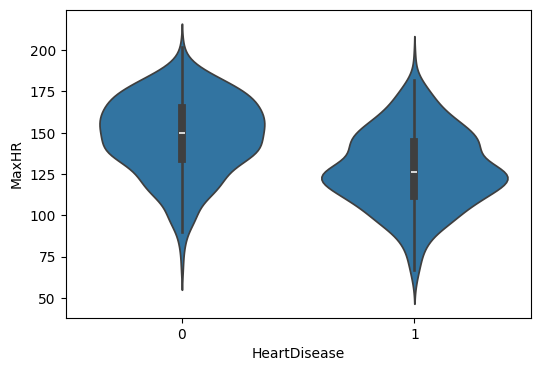

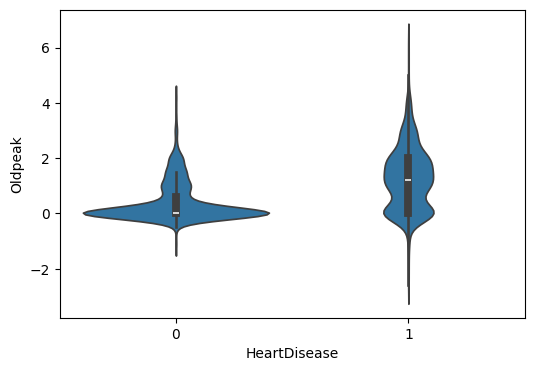

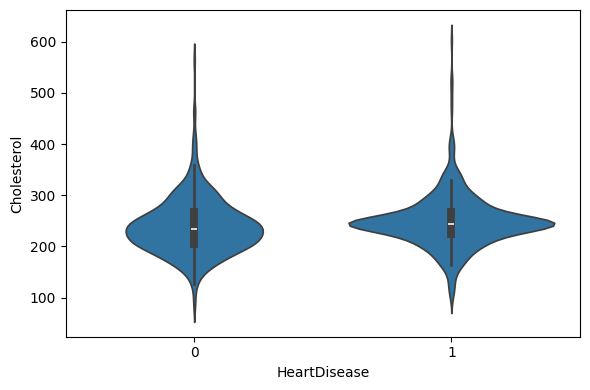

In [21]:
def violin_ploting (var , he):
    plt.figure(figsize = (6,4))
    sns.violinplot( y = df[he] ,x = df[var] , data = df)

violin_ploting('HeartDisease','Age')
violin_ploting('HeartDisease','RestingBP')
violin_ploting('HeartDisease','FastingBS')
violin_ploting('HeartDisease','MaxHR')
violin_ploting('HeartDisease','Oldpeak')
violin_ploting('HeartDisease','Cholesterol')


plt.tight_layout()

<Axes: >

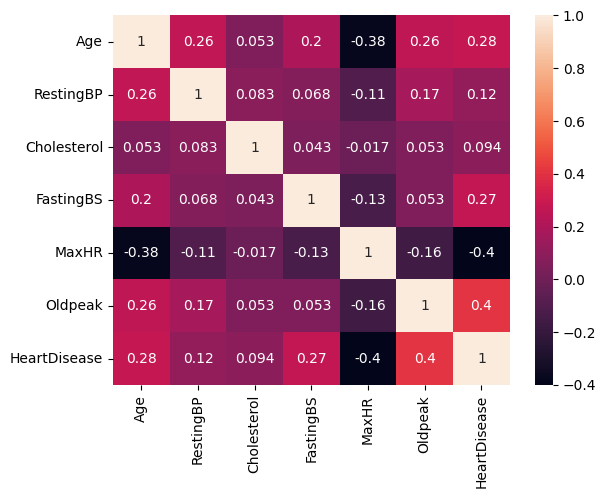

In [22]:
sns.heatmap(df.corr(numeric_only = True) , annot = True)

# Data preprocessing

In [23]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [24]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

# Level encoding

In [25]:
df['Sex'] = df['Sex'].map({'M':0 , 'F':1})

In [26]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,0,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,0,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,1,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [27]:
df['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [28]:
df['ExerciseAngina'] = df['ExerciseAngina'].map({
    'N':0,
    'Y':1
})

In [29]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140.0,289.0,0,Normal,172,0,0.0,Up,0
1,49,1,NAP,160.0,180.0,0,Normal,156,0,1.0,Flat,1
2,37,0,ATA,130.0,283.0,0,ST,98,0,0.0,Up,0
3,48,1,ASY,138.0,214.0,0,Normal,108,1,1.5,Flat,1
4,54,0,NAP,150.0,195.0,0,Normal,122,0,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,TA,110.0,264.0,0,Normal,132,0,1.2,Flat,1
914,68,0,ASY,144.0,193.0,1,Normal,141,0,3.4,Flat,1
915,57,0,ASY,130.0,131.0,0,Normal,115,1,1.2,Flat,1
916,57,1,ATA,130.0,236.0,0,LVH,174,0,0.0,Flat,1


# One hot Encoding 

In [30]:
encoded_df = pd.get_dummies(df , drop_first = True)

In [31]:
encoded_df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140.0,289.0,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,1,160.0,180.0,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,0,130.0,283.0,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,1,138.0,214.0,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,0,150.0,195.0,0,122,0,0.0,0,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110.0,264.0,0,132,0,1.2,1,False,False,True,True,False,True,False
914,68,0,144.0,193.0,1,141,0,3.4,1,False,False,False,True,False,True,False
915,57,0,130.0,131.0,0,115,1,1.2,1,False,False,False,True,False,True,False
916,57,1,130.0,236.0,0,174,0,0.0,1,True,False,False,False,False,True,False


In [32]:
encoded_df = encoded_df.astype(int)
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
5,39,0,120,339,0,170,0,0,0,0,1,0,1,0,0,1
6,45,1,130,237,0,170,0,0,0,1,0,0,1,0,0,1
7,54,0,110,208,0,142,0,0,0,1,0,0,1,0,0,1
8,37,0,140,207,0,130,1,1,1,0,0,0,1,0,1,0
9,48,1,120,284,0,120,0,0,0,1,0,0,1,0,0,1


In [33]:
encoded_df.shape

(918, 16)

In [34]:
encoded_df.duplicated().sum()

np.int64(0)

In [35]:
encoded_df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1,1,0,0,1,1,0,1,0
914,68,0,144,193,1,141,0,3,1,0,0,0,1,0,1,0
915,57,0,130,131,0,115,1,1,1,0,0,0,1,0,1,0
916,57,1,130,236,0,174,0,0,1,1,0,0,0,0,1,0


In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [37]:
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
5,39,0,120,339,0,170,0,0,0,0,1,0,1,0,0,1
6,45,1,130,237,0,170,0,0,0,1,0,0,1,0,0,1
7,54,0,110,208,0,142,0,0,0,1,0,0,1,0,0,1
8,37,0,140,207,0,130,1,1,1,0,0,0,1,0,1,0
9,48,1,120,284,0,120,0,0,0,1,0,0,1,0,0,1


In [38]:
encoded_df.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [39]:
from scipy.stats import pearsonr

selected_feature = ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']

correlation = {
    feature: pearsonr(encoded_df[feature] , encoded_df['HeartDisease']) [0]
    for feature in selected_feature
}
correlation_df = pd.DataFrame(list(correlation.items()), columns = ['Feature' , 'Pearsonr Correlation'])
correlation_df.sort_values(by = 'Pearsonr Correlation', ascending = False)

,Feature,Pearsonr Correlation
13,ST_Slope_Flat,0.554134
6,ExerciseAngina,0.494282
7,Oldpeak,0.392385
0,Age,0.282039
4,FastingBS,0.267291
2,RestingBP,0.117909
12,RestingECG_ST,0.102527
3,Cholesterol,0.092586
10,ChestPainType_TA,-0.054790
11,RestingECG_Normal,-0.091580


<Axes: >

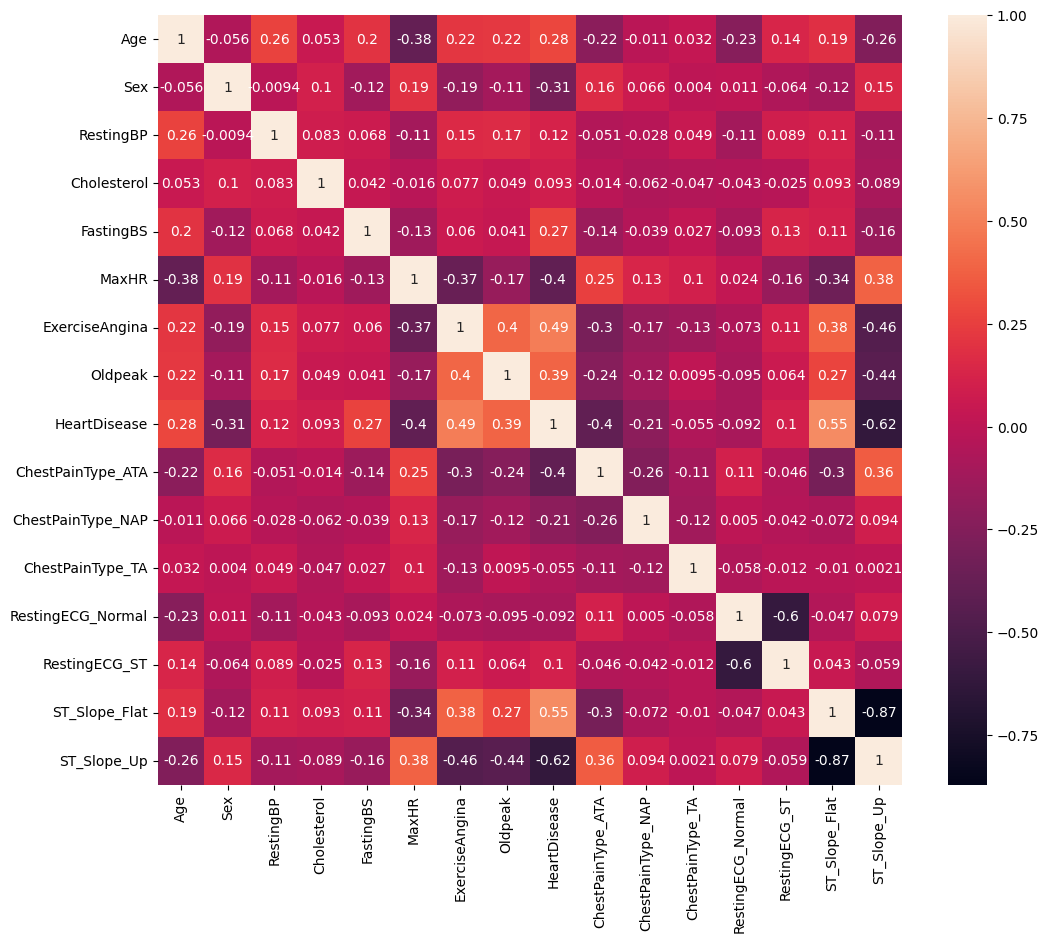

In [40]:
plt.figure(figsize = (12 , 10))
sns.heatmap(encoded_df.corr(numeric_only = True) , annot=True)

In [41]:
encoded_df.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [42]:
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
5,39,0,120,339,0,170,0,0,0,0,1,0,1,0,0,1
6,45,1,130,237,0,170,0,0,0,1,0,0,1,0,0,1
7,54,0,110,208,0,142,0,0,0,1,0,0,1,0,0,1
8,37,0,140,207,0,130,1,1,1,0,0,0,1,0,1,0
9,48,1,120,284,0,120,0,0,0,1,0,0,1,0,0,1


In [43]:
final_columns = ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease','ChestPainType_ATA',
       'ChestPainType_NAP','RestingECG_Normal','ChestPainType_TA',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']
encoded_df = encoded_df[final_columns]
encoded_df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,ChestPainType_TA,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,1,0,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,1,0,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,1,0,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1,1,0,0,1,1,0,1,0
914,68,0,144,193,1,141,0,3,1,0,0,1,0,0,1,0
915,57,0,130,131,0,115,1,1,1,0,0,1,0,0,1,0
916,57,1,130,236,0,174,0,0,1,1,0,0,0,0,1,0


In [44]:
encoded_df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,ChestPainType_TA,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,1,0,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,1,0,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,1,0,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,1,0,0,0,1
5,39,0,120,339,0,170,0,0,0,0,1,1,0,0,0,1
6,45,1,130,237,0,170,0,0,0,1,0,1,0,0,0,1
7,54,0,110,208,0,142,0,0,0,1,0,1,0,0,0,1
8,37,0,140,207,0,130,1,1,1,0,0,1,0,0,1,0
9,48,1,120,284,0,120,0,0,0,1,0,1,0,0,0,1


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , f1_score , classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score

In [46]:
X = encoded_df.drop('HeartDisease' , axis = 1)
y = encoded_df['HeartDisease']

In [47]:
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled , columns=[['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak','ChestPainType_ATA',
       'ChestPainType_NAP','RestingECG_Normal','ChestPainType_TA',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']])
X_scaled

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,ChestPainType_TA,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,-0.515952,0.414885,0.834754,-0.551341,1.382928,-0.823556,-0.727592,2.075177,-0.532838,0.814275,-0.229679,-0.490449,-1.002181,1.150674
1,-0.478484,1.938163,1.527224,-1.210675,-0.551341,0.754157,-0.823556,0.282891,-0.481887,1.876744,0.814275,-0.229679,-0.490449,0.997824,-0.869056
2,-1.751359,-0.515952,-0.141284,0.722161,-0.551341,-1.525138,-0.823556,-0.727592,2.075177,-0.532838,-1.228087,-0.229679,2.038947,-1.002181,1.150674
3,-0.584556,1.938163,0.303651,-0.572651,-0.551341,-1.132156,1.214246,0.282891,-0.481887,-0.532838,0.814275,-0.229679,-0.490449,0.997824,-0.869056
4,0.051881,-0.515952,0.971054,-0.929194,-0.551341,-0.581981,-0.823556,-0.727592,-0.481887,1.876744,0.814275,-0.229679,-0.490449,-1.002181,1.150674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-0.515952,-1.253622,0.365619,-0.551341,-0.188999,-0.823556,0.282891,-0.481887,-0.532838,0.814275,4.353909,-0.490449,0.997824,-0.869056
914,1.536902,-0.515952,0.637353,-0.966725,1.813758,0.164684,-0.823556,2.303858,-0.481887,-0.532838,0.814275,-0.229679,-0.490449,0.997824,-0.869056
915,0.370100,-0.515952,-0.141284,-2.130180,-0.551341,-0.857069,1.214246,0.282891,-0.481887,-0.532838,0.814275,-0.229679,-0.490449,0.997824,-0.869056
916,0.370100,1.938163,-0.141284,-0.159813,-0.551341,1.461525,-0.823556,-0.727592,2.075177,-0.532838,-1.228087,-0.229679,-0.490449,0.997824,-0.869056


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

In [49]:
models = {
    'LogisticRegression':LogisticRegression(),
    'GaussianNB':GaussianNB(),
    'KNeighborsClassifier':KNeighborsClassifier(metric='manhattan',n_neighbors=9,weights= 'distance'),
    'SVC':SVC(gamma='auto',C=1.0,kernel='rbf'),
    'DecisionTreeClassifier':DecisionTreeClassifier()
}

In [50]:
model_svm = SVC(gamma='auto')
model_svm.fit(X_train , y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [51]:
result = []

In [52]:
for name,model in models.items():
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        'model':name,
        'accuracy':round(acc*100 , 4),
        'f1 score':round(f1*100 , 4),
    })

In [53]:
from sklearn.model_selection import cross_val_score
for name,model in models.items():
    score = cross_val_score(model , X_train , y_train , cv = 15 , scoring='accuracy')
    print(name , score.mean()*100)

LogisticRegression 85.01133786848072
GaussianNB 84.7278911564626
KNeighborsClassifier 87.04931972789115
SVC 85.54705215419501
DecisionTreeClassifier 74.6485260770975


In [54]:
result

[{'model': 'LogisticRegression', 'accuracy': 86.9565, 'f1 score': 88.4615},
 {'model': 'GaussianNB', 'accuracy': 84.7826, 'f1 score': 86.1386},
 {'model': 'KNeighborsClassifier', 'accuracy': 86.413, 'f1 score': 87.9227},
 {'model': 'SVC', 'accuracy': 84.7826, 'f1 score': 86.6667},
 {'model': 'DecisionTreeClassifier', 'accuracy': 79.3478, 'f1 score': 81.5534}]

In [55]:
linear = LinearRegression()

In [56]:
linear_model = linear.fit(X_train , y_train)
linear_y_pred = linear_model.predict(X_test)

In [57]:
r2 = r2_score(y_test,linear_y_pred)
r2

0.5340870684974326

In [58]:
n = X.shape[0]
p = X.shape[1]

In [59]:
adjusted_r2 = 1 - ((1 - r2) * ( n - 1) / ( n - p - 1))
adjusted_r2

0.5263390707451726

# Grid search cv

In [60]:
from sklearn.model_selection import GridSearchCV
parameters = {'kernel':('linear', 'rbf'), 'C':[1,10,20,30]}
classifier = GridSearchCV(estimator=model_svm,param_grid=parameters,cv=5,return_train_score = False)

In [61]:
classifier.fit(X_train , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(gamma='auto')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'kernel': ('linear', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [62]:
result = pd.DataFrame(classifier.cv_results_)
results = result[['param_C' , 'param_kernel','mean_test_score']]
results

,param_C,param_kernel,mean_test_score
0,1,linear,0.848756
1,1,rbf,0.852856
2,10,linear,0.852838
3,10,rbf,0.828311
4,20,linear,0.852838
5,20,rbf,0.810577
6,30,linear,0.851477
7,30,rbf,0.803755


In [63]:
print(classifier.best_params_)
print(classifier.best_score_)

{'C': 1, 'kernel': 'rbf'}
0.8528562109775416


In [64]:
model_knn = KNeighborsClassifier(n_neighbors=15)

In [65]:
parameters_knn = {
    'n_neighbors': [3, 5, 7, 9 , 11 , 15 , 17 , 19 , 21 , 23 , 25],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

classifier_knn = GridSearchCV(
    estimator=model_knn,
    param_grid=parameters_knn,
    cv=5,
    return_train_score=False
)

In [66]:
classifier_knn.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla..._neighbors=15)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [67]:
result_knn = pd.DataFrame(classifier_knn.cv_results_)
results_knn = result_knn[['param_metric','param_n_neighbors','param_weights','mean_test_score']]
results_knn

,param_metric,param_n_neighbors,param_weights,mean_test_score
0,euclidean,3,uniform,0.840565
1,euclidean,3,distance,0.839204
2,euclidean,5,uniform,0.852838
3,euclidean,5,distance,0.852838
4,euclidean,7,uniform,0.858308
5,euclidean,7,distance,0.861019
6,euclidean,9,uniform,0.852838
7,euclidean,9,distance,0.854198
8,euclidean,11,uniform,0.858280
9,euclidean,11,distance,0.859640


In [68]:
print(classifier_knn.best_params_)
print(classifier_knn.best_score_)

{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
0.867831516168111


In [69]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators= 200, min_samples_split= 5, min_samples_leaf=1, max_depth=None, criterion= 'gini')

In [70]:
model_rf.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [71]:
y_pred_rf = model_rf.predict(X_test)

In [72]:
acc = accuracy_score(y_test , y_pred_rf)
print(acc)
f1_rf = f1_score(y_test , y_pred_rf)
print(f1_rf)

0.8695652173913043
0.8878504672897196


In [73]:
from sklearn.model_selection import RandomizedSearchCV

In [74]:
parameters = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10 , 15],
    'min_samples_leaf': [1, 2, 4 , 6],
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=parameters,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    return_train_score=False
)

In [75]:
random_search.fit(X_train , y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...stimators=200)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 

In [76]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}
0.8610194762836642


In [77]:
from xgboost import XGBClassifier

In [78]:
model_xg = XGBClassifier( subsample= 0.8, n_estimators=500, min_child_weight=3, max_depth= 10, learning_rate= 0.01, gamma= 0, colsample_bytree= 0.6)

In [79]:
model_xg.fit(X_train , y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [80]:
y_pred_xg = model_xg.predict(X_test)

In [81]:
acc = accuracy_score(y_test , y_pred_xg)
print(acc)
f1_rf = f1_score(y_test , y_pred_xg)
print(f1_rf)

0.8913043478260869
0.9065420560747663


In [82]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'min_child_weight': [1, 3, 5]
}

random_search_xg = RandomizedSearchCV(
    estimator=model_xg,
    param_distributions=param_dist,
    n_iter=20,  
    cv=5,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [83]:
random_search_xg.fit(X_train , y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [84]:
print(random_search_xg.best_params_)
print(random_search_xg.best_score_)

{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
0.8623986580933745


In [90]:
X_train

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,ChestPainType_TA,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
795,-1.220994,-0.515952,-0.697453,-0.084751,1.813758,2.247488,-0.823556,-0.727592,-0.481887,1.876744,0.814275,-0.229679,-0.490449,-1.002181,-0.869056
25,-1.857431,-0.515952,-0.141284,-0.666478,-0.551341,1.618717,-0.823556,-0.727592,-0.481887,1.876744,0.814275,-0.229679,-0.490449,-1.002181,1.150674
84,0.264027,-0.515952,0.971054,-0.591417,1.813758,-0.464087,1.214246,0.282891,-0.481887,-0.532838,0.814275,-0.229679,-0.490449,0.997824,-0.869056
10,-1.751359,1.938163,-0.141284,-0.628948,-0.551341,0.203982,-0.823556,-0.727592,-0.481887,1.876744,0.814275,-0.229679,-0.490449,-1.002181,1.150674
344,-0.266338,-0.515952,-0.697453,-0.009689,1.813758,-1.289349,-0.823556,-0.727592,-0.481887,-0.532838,0.814275,-0.229679,-0.490449,0.997824,-0.869056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.584556,1.938163,-0.697453,0.177965,-0.551341,-1.053560,-0.823556,-0.727592,-0.481887,-0.532838,-1.228087,-0.229679,2.038947,-1.002181,1.150674
270,-0.902775,-0.515952,-0.697453,-0.366232,-0.551341,0.125386,-0.823556,-0.727592,-0.481887,-0.532838,0.814275,-0.229679,-0.490449,-1.002181,1.150674
860,0.688318,-0.515952,-0.141284,0.159199,-0.551341,0.282579,1.214246,0.282891,-0.481887,-0.532838,0.814275,-0.229679,-0.490449,-1.002181,1.150674
435,0.688318,-0.515952,1.082288,-0.009689,-0.551341,-0.739174,1.214246,-0.727592,-0.481887,-0.532838,-1.228087,-0.229679,2.038947,-1.002181,1.150674


In [92]:
y_train

795    0
25     0
84     1
10     0
344    1
      ..
106    0
270    0
860    1
435    0
102    1
Name: HeartDisease, Length: 734, dtype: int64

In [86]:
import joblib
joblib.dump(models['LogisticRegression'] , 'logistic_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns_heart.pkl')

['columns_heart.pkl']

In [87]:
joblib.dump(models['KNeighborsClassifier'] , 'knn_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns_heart.pkl')

['columns_heart.pkl']

In [88]:
joblib.dump(model_rf , 'random_forest_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns_heart.pkl')

['columns_heart.pkl']

In [89]:
joblib.dump(model_xg , 'xgboost_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns_heart.pkl')

['columns_heart.pkl']